<a href="https://colab.research.google.com/github/csu-techhub/QAOA-portfolio/blob/main/ai_sci3_portfolio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install openai scikit-learn matplotlib pandas numpy requests

In [2]:
import os
from google.colab import userdata

# Store your key in Colab Secrets (left panel → 🔑 icon)
# then access it like this:
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
os.environ["SEMANTIC_SCHOLAR_API_KEY"] = userdata.get('SEMANTIC_SCHOLAR_API_KEY').strip()

In [3]:
import os
import json
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from openai import OpenAI

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report

In [4]:
#Cell 4
client = OpenAI() #api_key=os.environ["OPENAI_API_KEY"])

S2_API_KEY = os.environ.get("SEMANTIC_SCHOLAR_API_KEY", "")
S2_HEADERS = {"x-api-key": S2_API_KEY} if S2_API_KEY else {}
#S2_API_KEY = os.environ["SEMANTIC_SCHOLAR_API_KEY"]
#S2_HEADERS = {"x-api-key": S2_API_KEY}

In [ ]:
#XXXXXXXcell 5XXXXXXXXXXXXXXXXXXXXXXXXXX
iris = load_iris()
X = iris.data
y = iris.target

print("Feature names:", iris.feature_names)
print("Target names:", iris.target_names)
print("Shape:", X.shape)

df = pd.DataFrame(X, columns=iris.feature_names)
df["target"] = y
df.head()

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
Shape: (150, 4)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
#Cell 6 — Baseline experimentXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

baseline_model = LogisticRegression(max_iter=500)
baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)
baseline_acc = accuracy_score(y_test, baseline_pred)

print("Baseline accuracy:", baseline_acc)
print(classification_report(y_test, baseline_pred, target_names=iris.target_names))

Baseline accuracy: 0.9666666666666667
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



OpenAI API: idea generation

The official OpenAI developer docs provide the API reference and getting-started material for programmatic model calls.

In [5]:
#Cell 7 — Ask OpenAI for one simple idea
idea_prompt = f"""
You are an AI scientist.

We are doing a very small QAOA experiment on the portfolio optimization problem.
As the problem size gets bigger, it becomes intractable. We're interested in solving the problem using quantum computer, particularly QAOA (Quantum Approximate Optimization Algorithm).
More specifically, we'd like to apply the idea of truncation (or dropout) so that the quantum circuit complexity grows close to linearly rather than exponentially.
Baseline:
- Task: QAOA circuit for portfolio otimization
- Model: QAOA circuit
- Features: circuit depth and the number of qubits required

Propose exactly ONE simple, testable improvement that can be implemented in Qiskit.

Return valid JSON with fields:
- idea_name
- hypothesis
- exact_change
- search_queries   # 3 short Semantic Scholar search queries relevant to the idea
- expected_effect
"""

resp = client.responses.create(
    model="gpt-5",
    input=idea_prompt
)

idea_text = resp.output_text
print(idea_text)

{
  "idea_name": "Top-k covariance truncation for sparse QAOA cost Hamiltonian",
  "hypothesis": "Zeroing all but the top-k absolute covariance couplings per asset sparsifies the Ising graph, reducing two-qubit ZZ terms from O(n^2) to O(nk). For small k (e.g., 3–5), portfolio quality should remain close to baseline while circuit depth and two-qubit gate count grow near-linearly with n.",
  "exact_change": "Implement k-nearest covariance truncation before building the QuadraticProgram/QUBO used by QAOA.\n\nSteps (Qiskit):\n1) Compute a truncated covariance matrix keeping only top-k absolute off-diagonal entries per row (and symmetrize):\n   \n   import numpy as np\n   \n   def truncate_covariance(Sigma, k):\n       n = Sigma.shape[0]\n       keep = np.zeros_like(Sigma, dtype=bool)\n       for i in range(n):\n           idx = np.argsort(np.abs(Sigma[i]))[::-1]\n           idx = [j for j in idx if j != i][:k]\n           keep[i, idx] = True\n       mask = np.logical_or(keep, keep.T)\n    

In [6]:
#Cell 8 — Parse the idea JSON
idea_json = json.loads(idea_text)
idea_json

{'idea_name': 'Top-k covariance truncation for sparse QAOA cost Hamiltonian',
 'hypothesis': 'Zeroing all but the top-k absolute covariance couplings per asset sparsifies the Ising graph, reducing two-qubit ZZ terms from O(n^2) to O(nk). For small k (e.g., 3–5), portfolio quality should remain close to baseline while circuit depth and two-qubit gate count grow near-linearly with n.',
 'exact_change': 'Implement k-nearest covariance truncation before building the QuadraticProgram/QUBO used by QAOA.\n\nSteps (Qiskit):\n1) Compute a truncated covariance matrix keeping only top-k absolute off-diagonal entries per row (and symmetrize):\n   \n   import numpy as np\n   \n   def truncate_covariance(Sigma, k):\n       n = Sigma.shape[0]\n       keep = np.zeros_like(Sigma, dtype=bool)\n       for i in range(n):\n           idx = np.argsort(np.abs(Sigma[i]))[::-1]\n           idx = [j for j in idx if j != i][:k]\n           keep[i, idx] = True\n       mask = np.logical_or(keep, keep.T)\n       Si

Semantic Scholar API: novelty and literature search

Semantic Scholar’s Academic Graph API supports paper search and related scholarly metadata, and their official docs/tutorial describe Python usage for search endpoints.

In [11]:
#cell 9
import time

def s2_search_papers(query, limit=5, max_retries=5):
    url = "https://api.semanticscholar.org/graph/v1/paper/search"
    params = {
        "query": query,
        "limit": limit,
        "fields": "title,year,authors,abstract,venue,url,citationCount"
    }
    headers = {"x-api-key": S2_API_KEY} if S2_API_KEY else {}

    for attempt in range(max_retries):
        r = requests.get(url, params=params, headers=headers, timeout=30)

        if r.status_code == 200:
            return r.json()

        if r.status_code == 429:
            retry_after = r.headers.get("Retry-After")
            wait_time = float(retry_after) if retry_after is not None else 2 ** attempt
            print(f"Rate limited on attempt {attempt + 1}. Waiting {wait_time:.1f}s...")
            time.sleep(wait_time)
            continue

        r.raise_for_status()

    raise RuntimeError(f"Rate limit persisted after {max_retries} retries for query: '{query}'")


search_queries = idea_json.get("search_queries")
if not search_queries:
    raise KeyError("'search_queries' not found or empty in idea_json")

all_s2_results = []
for i, q in enumerate(search_queries):
    result = s2_search_papers(q, limit=5)
    all_s2_results.append({"query": q, "result": result})
    if i < len(search_queries) - 1:   # sleep between requests, not after the last
        time.sleep(1.1)

all_s2_results[:1]

[{'query': 'QAOA sparse Hamiltonian truncation',
  'result': {'total': 36,
   'offset': 0,
   'next': 5,
   'data': [{'paperId': 'd1f03af6fcd7c3e36cc33a94467feb0018d2fd12',
     'url': 'https://www.semanticscholar.org/paper/d1f03af6fcd7c3e36cc33a94467feb0018d2fd12',
     'title': 'Connecting the Hamiltonian structure to the QAOA performance and energy landscape',
     'venue': 'Jahrestagung der Gesellschaft für Informatik',
     'year': 2024,
     'citationCount': 0,
     'openAccessPdf': {'url': '',
      'status': None,
      'license': None,
      'disclaimer': 'Notice: Paper or abstract available at https://arxiv.org/abs/2407.04435, which is subject to the license by the author or copyright owner provided with this content. Please go to the source to verify the license and copyright information for your use.'},
     'authors': [{'authorId': '47168736', 'name': 'Daniel Müssig'},
      {'authorId': '2287332203', 'name': 'Markus Wappler'},
      {'authorId': '2021310346', 'name': 'Ste

In [10]:
#Revised Cell 9 — Semantic Scholar (No API Key)XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
import time
import requests

def s2_search_papers(query, limit=5, sleep_time=1.0):
    """
    Semantic Scholar search without API key.
    Includes basic rate limiting and error handling.
    """
    url = "https://api.semanticscholar.org/graph/v1/paper/search"

    params = {
        "query": query,
        "limit": limit,
        "fields": "title,year,authors,abstract,venue,url,citationCount"
    }

    try:
        response = requests.get(url, params=params, timeout=30)

        # Handle rate limiting (429)
        if response.status_code == 429:
            print("Rate limited. Sleeping and retrying...")
            time.sleep(5)
            response = requests.get(url, params=params, timeout=30)

        response.raise_for_status()
        data = response.json()

        # Be polite to API (important without key)
        time.sleep(sleep_time)

        return data

    except Exception as e:
        print(f"Error for query '{query}':", e)
        return {"data": []}

# Run searches from LLM-generated queries
all_s2_results = []

for q in idea_json["search_queries"]:
    print(f"\nSearching: {q}")
    result = s2_search_papers(q, limit=5)
    all_s2_results.append({"query": q, "result": result})

# Quick preview
all_s2_results[0]


Searching: QAOA sparse Hamiltonian truncation
Rate limited. Sleeping and retrying...
Error for query 'QAOA sparse Hamiltonian truncation': 429 Client Error:  for url: https://api.semanticscholar.org/graph/v1/paper/search?query=QAOA+sparse+Hamiltonian+truncation&limit=5&fields=title%2Cyear%2Cauthors%2Cabstract%2Cvenue%2Curl%2CcitationCount

Searching: portfolio QUBO covariance sparsification
Rate limited. Sleeping and retrying...


KeyboardInterrupt: 

In [12]:
#Cell 10 — Summarize literature hits
def flatten_s2_hits(all_results):
    rows = []
    for item in all_results:
        query = item["query"]
        papers = item["result"].get("data", [])
        for p in papers:
            rows.append({
                "query": query,
                "title": p.get("title"),
                "year": p.get("year"),
                "venue": p.get("venue"),
                "citationCount": p.get("citationCount"),
                "url": p.get("url"),
                "abstract": p.get("abstract")
            })
    return pd.DataFrame(rows)

lit_df = flatten_s2_hits(all_s2_results)
lit_df.head(10)

,query,title,year,venue,citationCount,url,abstract
0,QAOA sparse Hamiltonian truncation,Connecting the Hamiltonian structure to the QA...,2024,Jahrestagung der Gesellschaft für Informatik,0,https://www.semanticscholar.org/paper/d1f03af6...,Quantum computing holds promise for outperform...
1,QAOA sparse Hamiltonian truncation,Quantum-Circuit Framework for Two-Stage Stocha...,2025,,0,https://www.semanticscholar.org/paper/d9c62a03...,Two-stage stochastic programming often discret...
2,QAOA sparse Hamiltonian truncation,Compact Circuits for Constrained Quantum Evolu...,2025,,1,https://www.semanticscholar.org/paper/9c8b360e...,We introduce a general framework for construct...
3,QAOA sparse Hamiltonian truncation,Variational Quantum Eigensolvers for Sparse Ha...,2020,Physical Review Letters,32,https://www.semanticscholar.org/paper/a3e1a27e...,Hybrid quantum-classical variational algorithm...
4,QAOA sparse Hamiltonian truncation,Adaptive sparse grid expansions of the vibrati...,2014,Journal of Chemical Physics,19,https://www.semanticscholar.org/paper/7ac8fa02...,None
5,portfolio QUBO covariance sparsification,Bridging Quantum Algorithms and Classical Fina...,2025,2025 1st IEEE Uttar Pradesh Section Women in E...,0,https://www.semanticscholar.org/paper/adbc9def...,This study explores the integration of quantum...
6,portfolio QUBO covariance sparsification,Efficient Solution of Portfolio Optimization P...,2023,,1,https://www.semanticscholar.org/paper/b45a2144...,The Markowitz mean-variance portfolio optimiza...
7,portfolio QUBO covariance sparsification,Achieving High-Quality Portfolio Optimization ...,2025,,2,https://www.semanticscholar.org/paper/f164a7db...,Portfolio optimization is a fundamental proble...
8,portfolio QUBO covariance sparsification,Quantum-Assisted Optimal Rebalancing with Unco...,2026,,0,https://www.semanticscholar.org/paper/37bc3e28...,We present a hybrid classical-quantum framewor...
9,portfolio QUBO covariance sparsification,Portfolio optimization in the pre-emerging mar...,2026,International Journal of Research In Business ...,0,https://www.semanticscholar.org/paper/4d12091a...,This study investigates portfolio optimization...


In [13]:
#Cell 11 — Ask OpenAI to assess novelty based on Semantic Scholar results
literature_context = lit_df[["title", "year", "venue", "citationCount", "abstract"]].fillna("").to_dict(orient="records")

novelty_prompt = f"""
You are helping with a tiny AI-scientist workflow.

Candidate idea:
{json.dumps(idea_json, indent=2)}

Related papers retrieved from Semantic Scholar:
{json.dumps(literature_context[:12], indent=2)}

Assess:
1. Is the idea likely novel for this QAOA for portfolio optimization problem?
2. Is it too close to standard practice?
3. Should we still run it as a pedagogical experiment?

Return valid JSON with:
- novelty_assessment
- overlap_with_prior_work
- recommendation
- concise_related_work_paragraph
"""

novelty_resp = client.responses.create(
    model="gpt-5",
    input=novelty_prompt
)

novelty_text = novelty_resp.output_text
print(novelty_text)

{
  "novelty_assessment": "Low-to-moderate novelty. Covariance truncation/thresholding and graph sparsification are longstanding in classical portfolio optimization, and QAOA literature already links Hamiltonian sparsity to shallower circuits. The specific \"top-k per row, symmetrized\" truncation applied to the QAOA portfolio QUBO is a reasonable heuristic, but not fundamentally new.",
  "overlap_with_prior_work": "High conceptual overlap with classical sparsification (hard-thresholding, banding, and graphical approaches) and with quantum results showing benefits and robustness of sparse Hamiltonians. The 2023 work on portfolio dimension reduction and sparsification explicitly discusses sparsifying covariances (with PSD preservation). The 2024 study on QAOA vs. sparsity indicates performance is largely robust to Hamiltonian density, aligning with the idea’s hypothesis. PRL 2020 on VQE for sparse Hamiltonians further underlines that sparse operators are advantageous, though not specifi

Run the proposed experiment

For a truly generic agent, you would ask the model to emit executable code. For safety and simplicity in Colab, I recommend letting OpenAI suggest the change, then you implement from a controlled menu. For this example, assume the idea is polynomial features.

In [ ]:
#Cell 12 — Modified experiment
modified_model = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    StandardScaler(),
    LogisticRegression(max_iter=1000)
)

modified_model.fit(X_train, y_train)
modified_pred = modified_model.predict(X_test)
modified_acc = accuracy_score(y_test, modified_pred)

print("Modified accuracy:", modified_acc)
print(classification_report(y_test, modified_pred, target_names=iris.target_names))

Modified accuracy: 0.9666666666666667
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



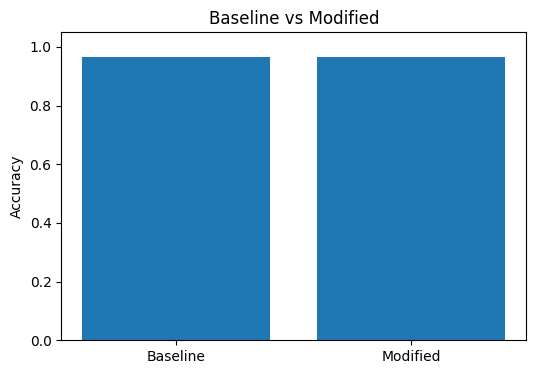

In [ ]:
#Cell 13 — Comparison plot
labels = ["Baseline", "Modified"]
values = [baseline_acc, modified_acc]

plt.figure(figsize=(6,4))
plt.bar(labels, values)
plt.ylim(0, 1.05)
plt.ylabel("Accuracy")
plt.title("Baseline vs Modified")
plt.show()

In [ ]:
#Make the result less noisy
#Cell 14 — Repeated splits
splitter = StratifiedShuffleSplit(n_splits=20, test_size=0.2, random_state=42)

baseline_scores = []
modified_scores = []

for train_idx, test_idx in splitter.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    baseline_model = LogisticRegression(max_iter=500)
    baseline_model.fit(X_train, y_train)
    baseline_scores.append(accuracy_score(y_test, baseline_model.predict(X_test)))

    modified_model = make_pipeline(
        PolynomialFeatures(degree=2, include_bias=False),
        StandardScaler(),
        LogisticRegression(max_iter=1000)
    )
    modified_model.fit(X_train, y_train)
    modified_scores.append(accuracy_score(y_test, modified_model.predict(X_test)))

print("Baseline mean:", np.mean(baseline_scores))
print("Modified mean:", np.mean(modified_scores))
print("Mean difference:", np.mean(modified_scores) - np.mean(baseline_scores))

Baseline mean: 0.9633333333333332
Modified mean: 0.9583333333333333
Mean difference: -0.004999999999999893


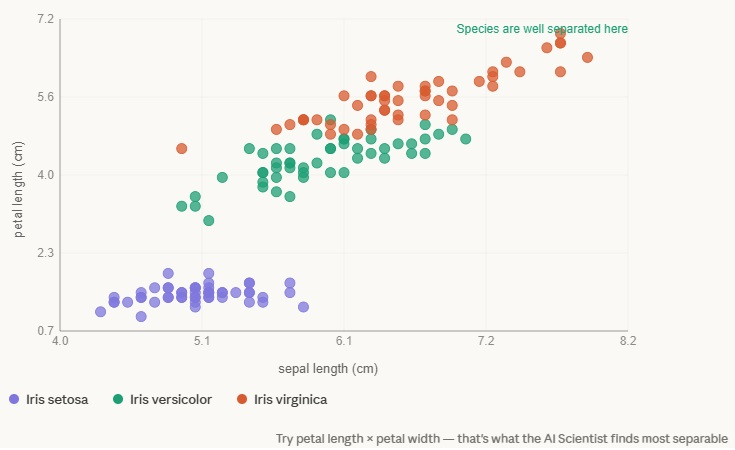

OpenAI API: report writing

In [ ]:
#Cell 15 — Ask OpenAI to write a short paper
paper_prompt = f"""
Write a concise ML-style report with sections:
- Introduction
- Method
- Results
- Discussion
- Limitations
- Conclusion

Use these facts only:

Problem:
We tested whether a simple feature transformation improves classification on the Iris dataset.

Baseline:
LogisticRegression on original features.
Single split accuracy = {baseline_acc:.4f}
Repeated-split mean accuracy = {np.mean(baseline_scores):.4f}

Modified method:
PolynomialFeatures(degree=2) + StandardScaler + LogisticRegression
Single split accuracy = {modified_acc:.4f}
Repeated-split mean accuracy = {np.mean(modified_scores):.4f}

Difference in repeated-split mean accuracy:
{np.mean(modified_scores) - np.mean(baseline_scores):.4f}

Related work / novelty notes:
{novelty_text}

Requirements:
- Under 500 words
- Do not exaggerate
- Say clearly this is a toy experiment
"""

paper_resp = client.responses.create(
    model="gpt-5",
    input=paper_prompt
)

paper_text = paper_resp.output_text
print(paper_text)

Introduction
This toy experiment tested whether a simple feature transformation improves classification accuracy on the Iris dataset.

Method
- Baseline: LogisticRegression on the original features.
- Modified: PolynomialFeatures(degree=2) followed by StandardScaler and LogisticRegression.
- Evaluation: accuracy on a single train/test split and mean accuracy over repeated splits.

Results
- Baseline
  - Single split accuracy: 0.9667
  - Repeated-split mean accuracy: 0.9633
- Modified
  - Single split accuracy: 0.9667
  - Repeated-split mean accuracy: 0.9583
- Difference in repeated-split mean accuracy (modified − baseline): −0.0050

Discussion
The modified pipeline matched the single-split accuracy of the baseline but yielded a slightly lower repeated-split mean accuracy (−0.0050). Under this setup, the added feature transformation did not improve performance on Iris.

Related work and novelty: Standardizing features before L2-regularized LogisticRegression is a well-established best p

OpenAI API: reviewer step

The paper uses an LLM reviewer to score manuscripts, and reports a GPT-4o-based reviewing setup for automated evaluation.

In [ ]:
#Cell 16 — Ask OpenAI to review the report
review_prompt = f"""
You are a strict reviewer for a short ML workshop paper.

Review the paper below.

Provide:
- summary
- strengths
- weaknesses
- questions
- soundness_score (1-5)
- clarity_score (1-5)
- significance_score (1-5)
- overall_score (1-10)
- decision (Accept or Reject)

Paper:
{paper_text}
"""

review_resp = client.responses.create(
    model="gpt-5",
    input=review_prompt
)

review_text = review_resp.output_text
print(review_text)

Summary
The paper evaluates whether adding degree-2 polynomial features with subsequent standardization improves Logistic Regression accuracy on the Iris dataset. Using a single train/test split and a “repeated-split mean accuracy,” the modified pipeline matches the single-split accuracy (0.9667) but slightly underperforms on average (−0.005). The authors conclude the feature transformation does not help on Iris and acknowledge the work has low novelty.

Strengths
- Clear, concise negative result communicated without overclaiming.
- Honest positioning with respect to prior practice and novelty.
- Simple setup that is easy to reproduce in principle.

Weaknesses
- Missing critical control: Logistic Regression with standardization but without polynomial features. Current comparison confounds scaling and polynomial expansion.
- Insufficient experimental rigor:
  - No details on the split protocol (train/test ratio, stratification, number of repeats, seeds).
  - No variance estimates, confi